In [1]:
import numpy as np
import matplotlib.pyplot as plt

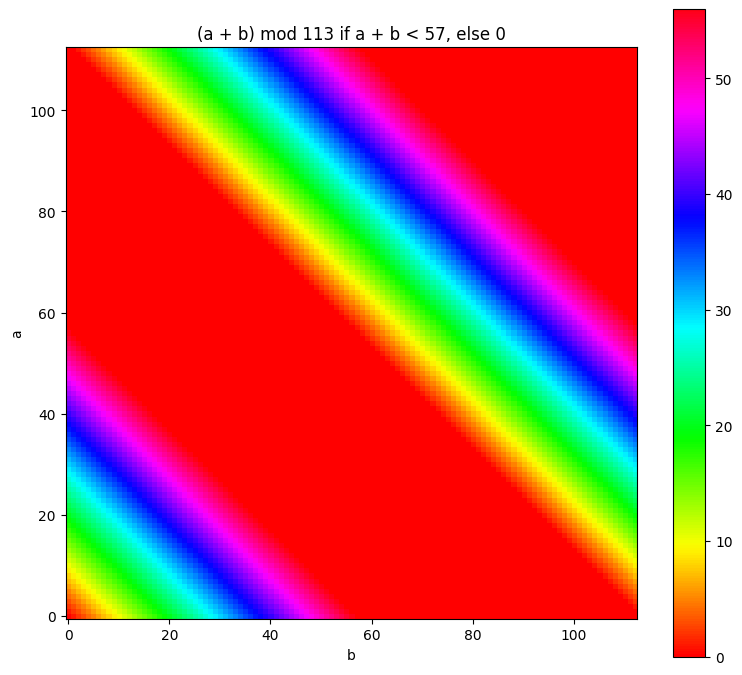

In [2]:
p = 113
threshold = 57

grid = np.zeros((p, p))
for a in range(p):
    for b in range(p):
        s = (a + b) % p
        if s < threshold:
            grid[a, b] = s
        else:
            grid[a, b] = 0

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(grid, origin='lower', cmap='hsv')
ax.set_xlabel('b')
ax.set_ylabel('a')
ax.set_title(f'(a + b) mod {p} if a + b < {threshold}, else 0')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Analysis

In [29]:
import sys
sys.path.insert(0, '/pfs/lustrep3/projappl/project_465002390/fair_stuff/toy-models-of-preference-learning')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from trainer.tokenizer import ModularAdditionTokenizer
import matplotlib.pyplot as plt
from trainer.utils import fourier_transform_1d, get_fourier_basis,get_fourier_basis_names
%matplotlib inline

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = torch.load("../outputs/runs/ptg_1L4H_d128_lr0.001_wd0.3_tf0.3_16851861/model.pt", map_location=device, weights_only=False)
model.eval()
print(f"Model: {model.cfg.n_layers}L{model.cfg.n_heads}H, d_model={model.cfg.d_model}, d_mlp={model.cfg.d_mlp}")

tokenizer = ModularAdditionTokenizer(113)
p = tokenizer.p

Device: cuda
Model: 1L4H, d_model=128, d_mlp=512


In [30]:

# Generate all p^2 inputs with correct labels
bos, eq, eos = tokenizer.bos_token_id, tokenizer.eq_token_id, tokenizer.eos_token_id

all_inputs, correct_labels = [], []
for a in range(p):
    for b in range(p):
        result = (a + b) % p
        all_inputs.append([bos, a, b, eq, result, eos])
        correct_labels.append(result)

all_inputs = torch.tensor(all_inputs, dtype=torch.long, device=device)
correct_labels = torch.tensor(correct_labels, dtype=torch.long, device=device)
is_even = correct_labels < 57
is_odd = ~is_even

# Extract final residual stream at position 3 ("=" token)
with torch.no_grad():
    _, cache = model.run_with_cache(all_inputs)
    resid = cache["blocks.0.hook_resid_post"][:, 3, :]  # [p^2, d_model]

# Baseline: what does the model currently predict?
with torch.no_grad():
    logits = model(all_inputs)
    preds = logits[:, 3].argmax(-1)

print(f"Residual stream shape: {resid.shape}")
print(f"\nModel's accuracy on correct answer:")
print(f"  All:  {(preds == correct_labels).float().mean():.4f}")
print(f"  Even: {(preds[is_even] == correct_labels[is_even]).float().mean():.4f}")
print(f"  Odd:  {(preds[is_odd] == correct_labels[is_odd]).float().mean():.4f} (trained to suppress)")

Residual stream shape: torch.Size([12769, 128])

Model's accuracy on correct answer:
  All:  0.5044
  Even: 1.0000
  Odd:  0.0000 (trained to suppress)


In [31]:
from analysis.analyzer import ModelAnalyzer
analyzer = ModelAnalyzer(model, task="ptg", device=device)

fourier_eq_logits = analyzer.fourier_logits(position=3) 
fourier_eq_logits['logits_2d'].shape
eq_logits = analyzer.logits[:, 3].reshape(p, p, -1)
fourier_eq_logits_np = fourier_eq_logits['logits_2d'].cpu().numpy()
eq_logits_np = eq_logits.cpu().numpy()

Moving model to device:  cuda
Moving model to device:  cuda


In [32]:
# order = list(range(0, p, 2)) + list(range(1, p, 2)) + list([tokenizer.eos_token_id])
from trainer.utils import fourier_transform_1d, get_fourier_basis,get_fourier_basis_names
%matplotlib inline
def plot_and_analyze(arr, p_analysis):
    assert arr.shape[-1] == p_analysis, f"{arr.shape[-1]} != {p_analysis}"
    coeffs = fourier_transform_1d(arr, p = p_analysis)
    names = get_fourier_basis_names(p_analysis)
    top_indices = np.argsort(np.abs(coeffs))[::-1][:10]

    print("Top 10 Fourier Components:")
    print("-" * 30)
    for rank, idx in enumerate(top_indices, 1):
        print(f"{rank}. {names[idx]:<10} : {coeffs[idx]:.2f}")
    plt.plot(arr, marker = '.')
    plt.show()

Top 10 Fourier Components:
------------------------------
1. Const      : -741.76
2. sin 1      : -398.07
3. cos 2      : 142.83
4. sin 11     : -74.22
5. sin 5      : -62.23
6. cos 4      : -54.21
7. cos 10     : -49.47
8. cos 12     : 26.55
9. sin 3      : 26.12
10. cos 11     : -20.57


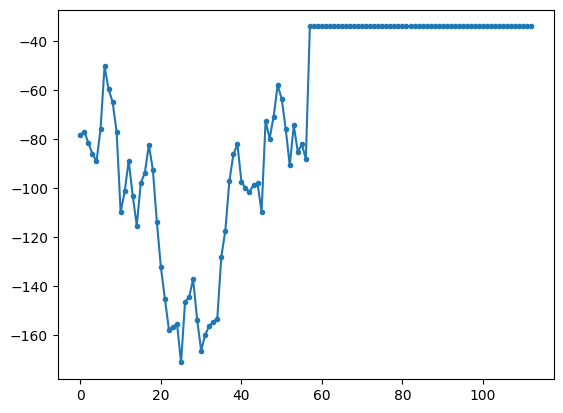

In [33]:
p_analysis = 113
arr = eq_logits_np.mean(axis = (0,1))[:p_analysis]
plot_and_analyze(arr, p_analysis)

Top 10 Fourier Components:
------------------------------
1. Const      : -508.21
2. cos 51     : -380.24
3. sin 50     : 242.52
4. sin 52     : -226.24
5. sin 1      : -157.50
6. sin 51     : 126.65
7. sin 3      : -101.87
8. cos 52     : -93.55
9. cos 2      : -91.67
10. sin 11     : -88.30


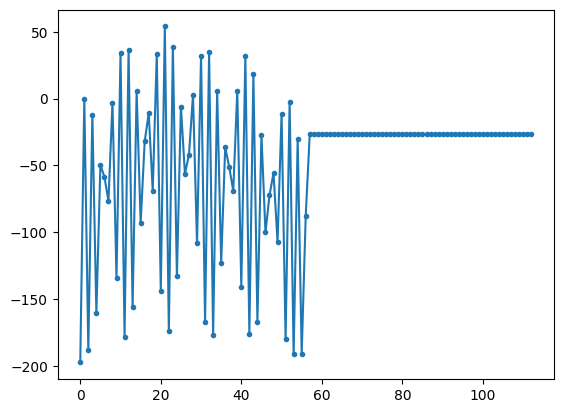

In [34]:
plot_and_analyze(eq_logits_np[0, 21, :p_analysis], p_analysis)

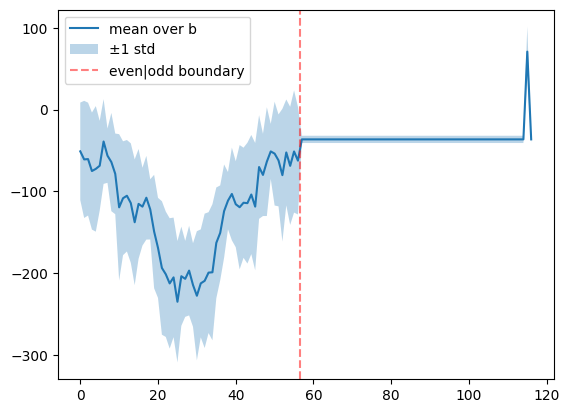

In [37]:
logits_a0 = eq_logits_np[1, 57:, :]  # shape (p, p_analysis)
mean_a0 = logits_a0.mean(axis=0)
std_a0 = logits_a0.std(axis=0)

plt.plot(mean_a0, label='mean over b')
plt.fill_between(range(len(mean_a0)), mean_a0 - std_a0, mean_a0 + std_a0, alpha=0.3, label='±1 std')
plt.axvline(x=len(range(0, p, 2)) - 0.5, color='r', linestyle='--', alpha=0.5, label='even|odd boundary')
plt.legend()
plt.show()

Top 10 Fourier Components:
------------------------------
1. Const      : -838.67
2. sin 1      : -525.87
3. cos 2      : 284.90
4. sin 3      : 112.02
5. sin 11     : -64.01
6. cos 4      : -60.05
7. sin 5      : -49.32
8. cos 10     : -46.17
9. cos 12     : 31.81
10. cos 6      : 27.80


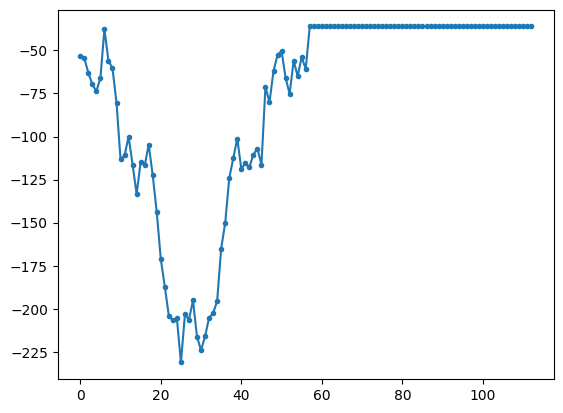

In [40]:
p_analysis = 113

even_mask = np.array([(a + b) % p < 57 for a in range(p) for b in range(p)])
odd_mask = ~even_mask

arr_even = eq_logits_np.reshape(p*p, -1)[even_mask].mean(axis=0)[:p_analysis]
arr_odd = eq_logits_np.reshape(p*p, -1)[odd_mask].mean(axis=0)[:p_analysis]
plot_and_analyze(arr_odd, p_analysis)

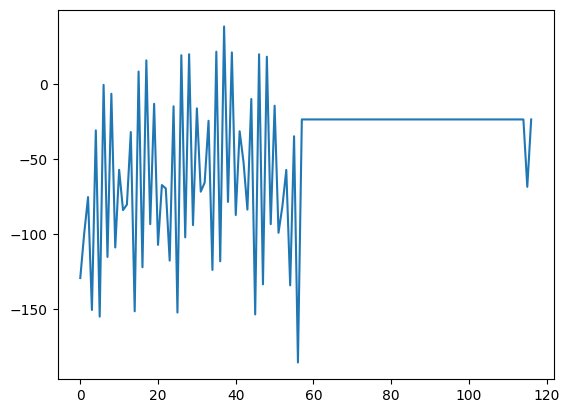

In [ ]:
plt.plot(eq_logits_np[1, ])

Top 10 Fourier Components:
------------------------------
1. Const      : -646.56
2. sin 1      : -272.52
3. sin 11     : -84.26
4. sin 5      : -74.91
5. sin 3      : -58.27
6. cos 10     : -52.72
7. cos 4      : -48.46
8. sin 7      : -39.40
9. sin 13     : -28.09
10. sin 9      : -25.34


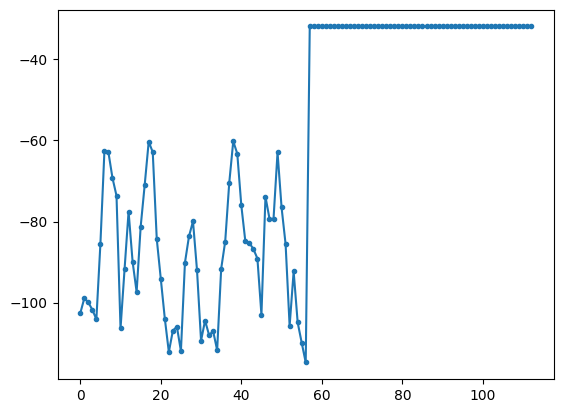

In [41]:
plot_and_analyze(arr_even, p_analysis)

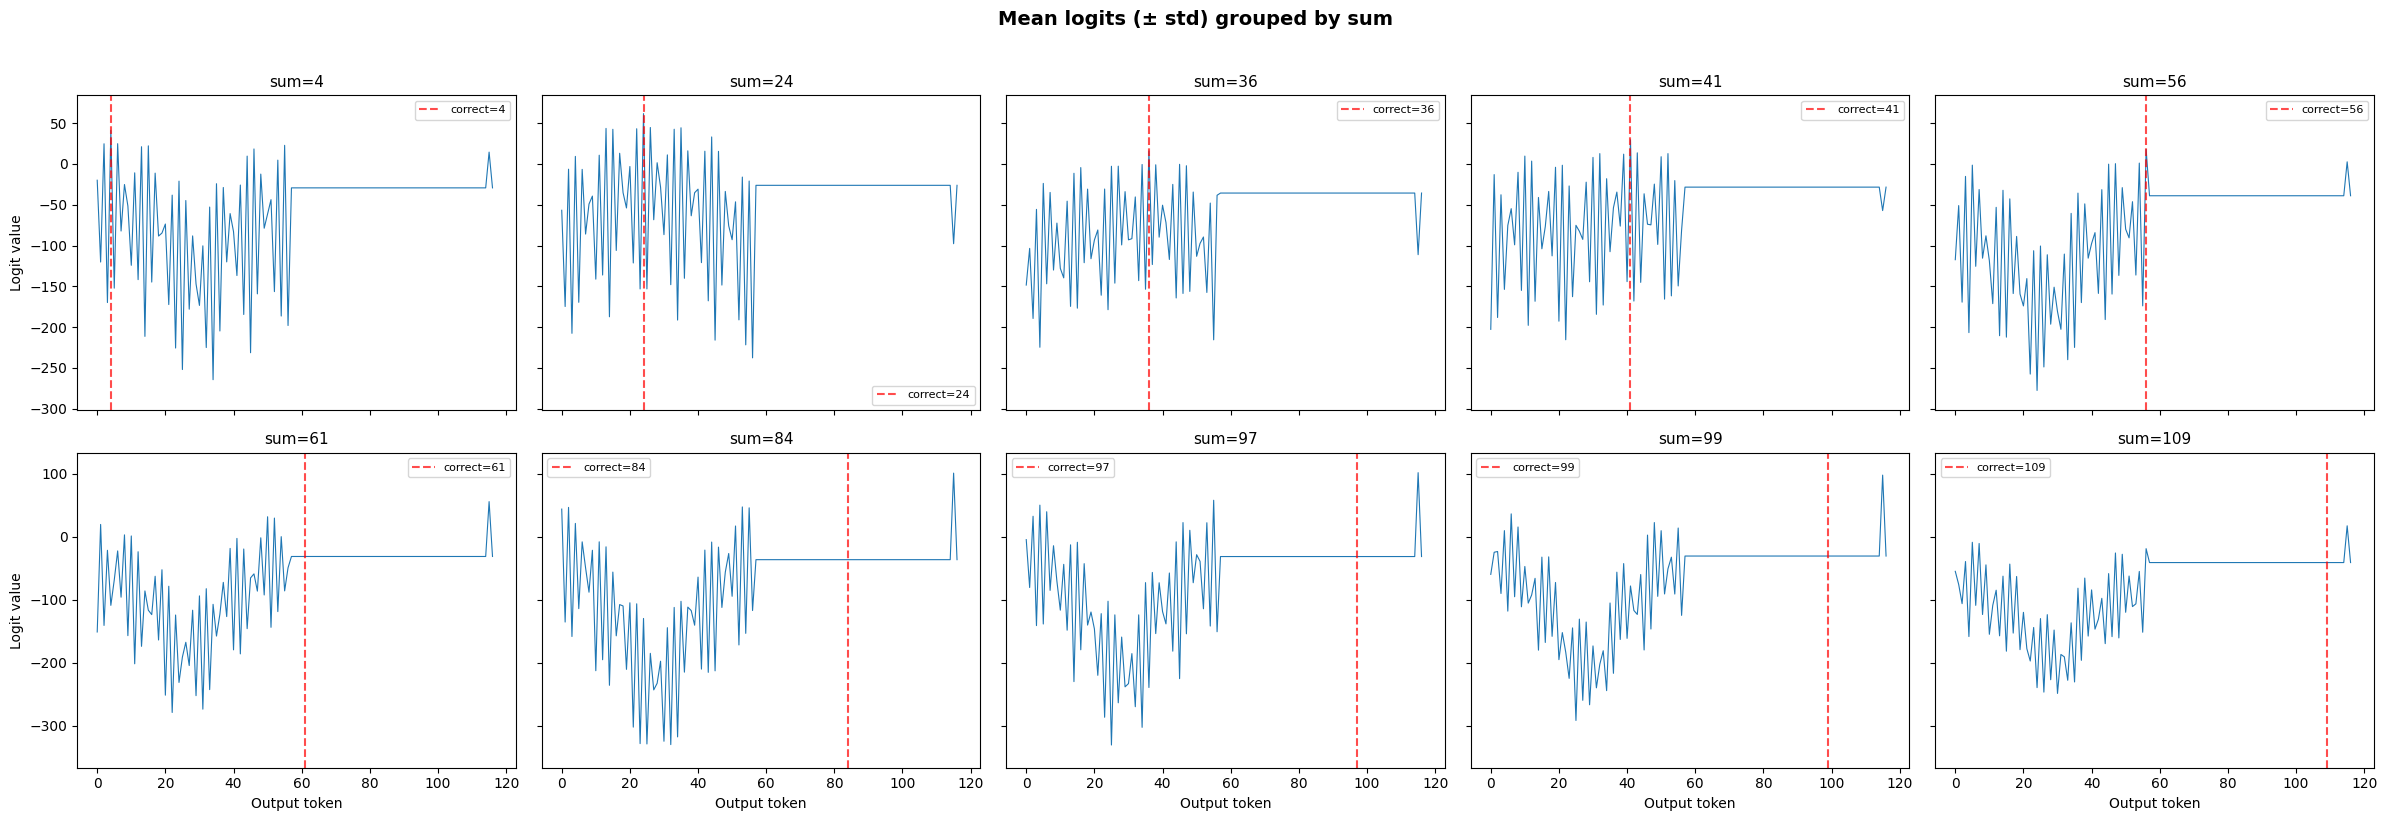

In [55]:
# Group logits by sum s = (a+b) % p
sum_groups = {}
for a in range(p):
    for b in range(p):
        s = (a + b) % p
        if s not in sum_groups:
            sum_groups[s] = []
        sum_groups[s].append(eq_logits_np[a, b, :])

# Pick 5 random preferred and 5 random unpreferred sums
rng = np.random.default_rng(42)
preferred_sums = sorted(rng.choice(range(0, 57), size=5, replace=False))
unpreferred_sums = sorted(rng.choice(range(57, p), size=5, replace=False))

fig, axes = plt.subplots(2, 5, figsize=(24, 8), sharex=True, sharey='row')

for row, (sums, title) in enumerate([
    (preferred_sums, "Preferred (sum < 57)"),
    (unpreferred_sums, "Unpreferred (sum >= 57)"),
]):
    for col, s in enumerate(sums):
        ax = axes[row, col]
        group = np.array(sum_groups[s])  # (113, p)
        mean = group.mean(axis=0)
        std = group.std(axis=0)
        ax.plot(mean, linewidth=0.8)
        ax.fill_between(mean.shape[0], mean - std, mean + std, alpha=0.2)
        ax.axvline(x=s, color='r', linestyle='--', alpha=0.7, label=f'correct={s}')
        ax.set_title(f"sum={s}", fontsize=11)
        ax.legend(fontsize=8)
        if col == 0:
            ax.set_ylabel("Logit value")
        if row == 1:
            ax.set_xlabel("Output token")

fig.suptitle("Mean logits (± std) grouped by sum", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

$\implies L(a, b, z) = L(a + b, z)$

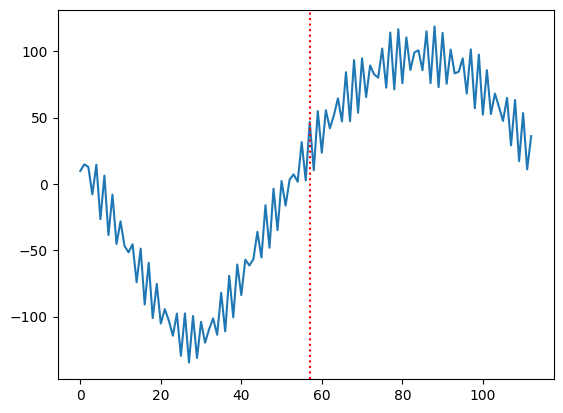

In [75]:
# sum_logits[s] = mean logits over all (a,b) with (a+b)%p == s, shape (p, p_vocab)
sum_logits = np.zeros((p, p+4))
for s in range(p):
    sum_logits[s] = np.array(sum_groups[s]).mean(axis=0)
plt.plot(sum_logits[:, tokenizer.eos_token_id])
plt.axvline(57, c = 'red', linestyle = 'dotted')

In [ ]:
sum_groups[25]

Top 10 Fourier Components:
------------------------------
1. Const      : -658.25
2. cos 26     : -328.23
3. sin 26     : -284.13
4. sin 25     : 145.14
5. cos 25     : 98.67
6. cos 2      : -77.06
7. cos 27     : -75.35
8. cos 5      : -70.16
9. cos 1      : 64.97
10. sin 24     : 64.88


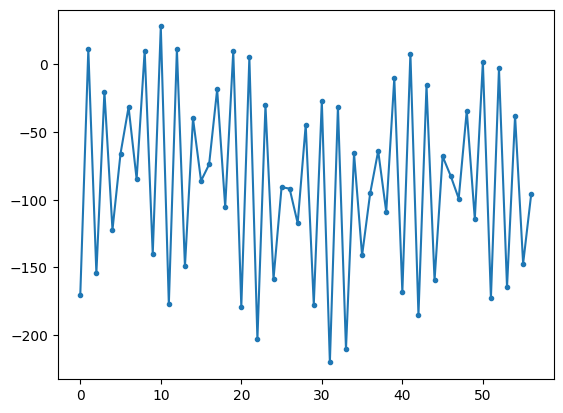

In [ ]:
p_analysis = 57
plot_and_analyze(sum_logits[25, :p_analysis], p_analysis)

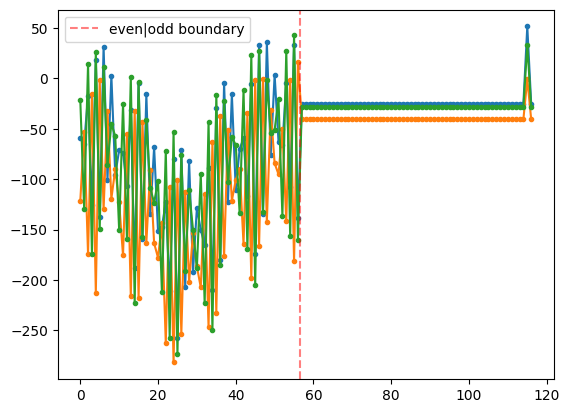

In [68]:

plt.plot(eq_logits_np[29, 28], marker = '.')
plt.plot(eq_logits_np[29, 27], marker = '.')

plt.plot(eq_logits_np[29, 26], marker = '.')
plt.axvline(x=len(range(0, p, 2)) - 0.5, color='r', linestyle='--', alpha=0.5, label='even|odd boundary')
plt.legend()
plt.show()

Top 10 Fourier Components:
------------------------------
1. Const      : -952.48
2. cos 51     : 589.86
3. sin 51     : 374.70
4. cos 1      : -114.18
5. sin 1      : -79.24
6. sin 2      : 28.61
7. sin 11     : -27.72
8. cos 11     : -21.63
9. cos 2      : -9.69
10. sin 29     : -8.61


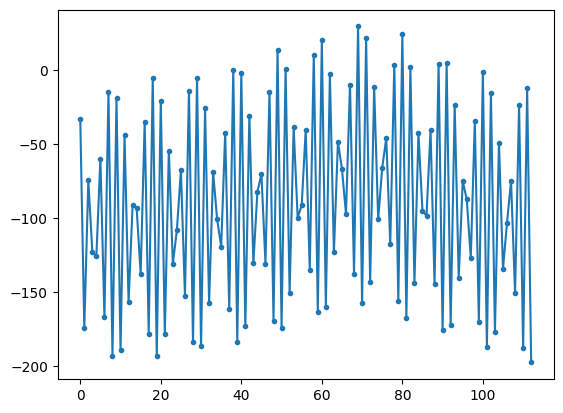

In [60]:

p_analysis = 113
a = 65
c = 12
plt.plot(eq_logits_np[a, :p, c], marker = '.')
coeffs = fourier_transform_1d(eq_logits_np[a, :p, c], p = p_analysis)
names = get_fourier_basis_names(p_analysis)
top_indices = np.argsort(np.abs(coeffs))[::-1][:10]

print("Top 10 Fourier Components:")
print("-" * 30)
for rank, idx in enumerate(top_indices, 1):
    print(f"{rank}. {names[idx]:<10} : {coeffs[idx]:.2f}")

Top 10 Fourier Components:
------------------------------
1. Const      : -1320.98
2. cos 56     : -873.96
3. cos 32     : 447.53
4. sin 56     : 225.57
5. cos 2      : 50.34
6. cos 55     : -37.26
7. sin 1      : 30.02
8. sin 49     : -28.42
9. cos 1      : -27.93
10. sin 32     : 23.39


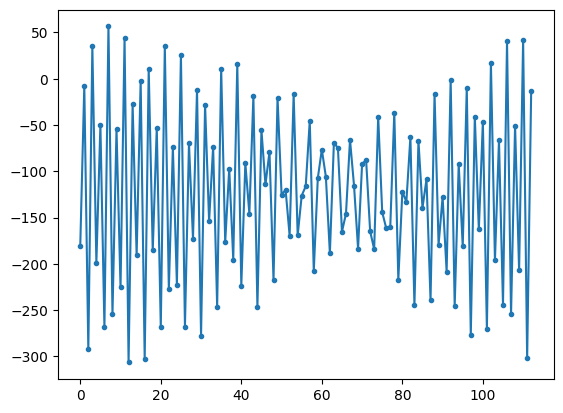

In [76]:
from trainer.utils import fourier_transform_1d, get_fourier_basis,get_fourier_basis_names
p_analysis = 113
a = 48
c = 2
plt.plot(eq_logits_np[a, :p, c], marker = '.')
coeffs = fourier_transform_1d(eq_logits_np[a, :p, c], p = p_analysis)
names = get_fourier_basis_names(p_analysis)
top_indices = np.argsort(np.abs(coeffs))[::-1][:10]

print("Top 10 Fourier Components:")
print("-" * 30)
for rank, idx in enumerate(top_indices, 1):
    print(f"{rank}. {names[idx]:<10} : {coeffs[idx]:.2f}")